In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "AirPassengers.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rakannimer/air-passengers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())


/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_1875/201398161.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 1.71k/1.71k [00:00<00:00, 2.00MB/s]

First 5 records:      Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


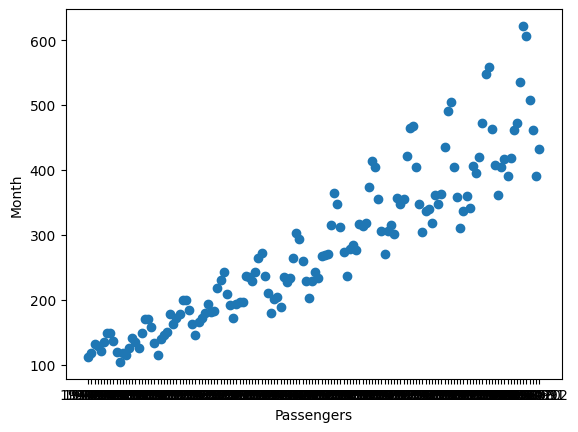

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df["Month"],df["#Passengers"])
plt.xlabel("Passengers")
plt.ylabel("Month")
plt.show()

In [5]:
%pip install tensorflow
%pip install statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Load dataset
data = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv",
    parse_dates=['Month'],
    index_col='Month'
)

y = data['Passengers']

y_log = np.log(y)

train_size = int(len(y_log) * 0.8)
train, test = y_log[:train_size], y_log[train_size:]

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

arima_pred = model_fit.forecast(steps=len(test))

residuals = model_fit.resid

X = []
y_res = []

for i in range(1, len(residuals)):
    X.append(residuals[i-1])
    y_res.append(residuals[i])

X = np.array(X).reshape(-1,1)
y_res = np.array(y_res)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

nn = Sequential()
nn.add(Dense(10, activation='relu', input_dim=1))
nn.add(Dense(1))
nn.compile(optimizer='adam', loss='mse')

nn.fit(X_scaled, y_res, epochs=100, verbose=0)

last_residual = residuals[-1]
last_res_scaled = scaler.transform([[last_residual]])

nn_residual_pred = nn.predict(last_res_scaled)

hybrid_pred = arima_pred + nn_residual_pred[0][0]

print("ARIMA forecast:", np.exp(arima_pred.values[0]))
print("Hybrid forecast:", np.exp(hybrid_pred.values[0]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.7/200.7 MB 4.8 MB/s  0:00:47m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 4.9 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 9.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 5.4 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [tensorflow]4 [tensorflow]]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kern

/Users/adityakulkarni28/Desktop/mlpract/myenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/adityakulkarni28/Desktop/mlpract/myenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/adityakulkarni28/Desktop/mlpract/myenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_1875/2231445160.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by po

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
ARIMA forecast: 477.4308901091374
Hybrid forecast: 489.596635975234


/var/folders/x2/zzlc6gjx425_qfb3j1dh0s6w0000gn/T/ipykernel_1875/2231445160.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_residual = residuals[-1]


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test_actual = np.exp(test)
arima_pred_actual = np.exp(arima_pred)
hybrid_pred_actual = np.exp(hybrid_pred)

mae = mean_absolute_error(test_actual, arima_pred_actual)

rmse = np.sqrt(mean_squared_error(test_actual, arima_pred_actual))

mape = np.mean(np.abs((test_actual - arima_pred_actual) / test_actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 62.62484877902186
RMSE: 82.8590461958816
MAPE: 13.738651658821135
